In [163]:
import pandas as pd

data = pd.read_csv('../data/processed/judge_v2/teacher_features_text_v1.csv', encoding='utf-8')
df = pd.DataFrame(data)

In [3]:
df.columns

Index(['case_id', 'category', 'question', 'dense_top1', 'dense_topk_mean',
       'dense_top1_top2_gap', 'dense_score_variance', 'dense_count',
       'dense_present', 'bm25_top1', 'bm25_topk_mean', 'bm25_top1_top2_gap',
       'bm25_score_variance', 'bm25_count', 'bm25_present', 'rrf_top1',
       'rrf_topk_mean', 'rrf_top1_top2_gap', 'rrf_score_variance', 'rrf_count',
       'rrf_present', 'rerank_top1', 'rerank_topk_mean',
       'rerank_top1_top2_gap', 'rerank_score_variance', 'rerank_count',
       'rerank_present', 'rerank_count_ge_0_5', 'text_top1_body_chars',
       'text_top5_body_chars_mean', 'text_top5_body_present_count',
       'text_top1_title_coverage', 'text_top5_title_coverage_max',
       'text_top5_body_coverage_max', 'text_top5_body_coverage_mean',
       'text_question_region_present', 'text_top5_region_match_count',
       'text_top5_region_conflict_count', 'text_top5_list_reference_count',
       'label', 'status'],
      dtype='str')

In [170]:
select = [
       'dense_top1_top2_gap', 'rrf_top1',
       'rerank_top1', 'rerank_topk_mean',
       'text_top5_body_chars_mean', 'text_top5_body_present_count',
       'text_question_region_present',
       'text_top5_region_match_count','label'
]

# select = ['dense_top1', 'dense_topk_mean',
#        'dense_top1_top2_gap', 'dense_score_variance',
#        'bm25_top1', 'bm25_topk_mean', 'bm25_top1_top2_gap',
#        'bm25_score_variance', 'bm25_count','rrf_top1',
#        'rrf_topk_mean', 'rrf_top1_top2_gap', 'rrf_score_variance',
#        'rerank_top1', 'rerank_topk_mean',
#        'rerank_top1_top2_gap', 'rerank_score_variance',
#        'rerank_count_ge_0_5', 'text_top1_body_chars',
#        'text_top5_body_chars_mean', 'text_top5_body_present_count',
#        'text_top1_title_coverage', 'text_top5_title_coverage_max',
#        'text_top5_body_coverage_max', 'text_top5_body_coverage_mean',
#        'text_question_region_present', 'text_top5_region_match_count',
#        'text_top5_region_conflict_count', 'text_top5_list_reference_count',
#        'label']

df = df[select]
df.columns

Index(['dense_top1_top2_gap', 'rrf_top1', 'rerank_top1', 'rerank_topk_mean',
       'text_top5_body_chars_mean', 'text_top5_body_present_count',
       'text_question_region_present', 'text_top5_region_match_count',
       'label'],
      dtype='str')

In [171]:
X = df.drop(columns='label')
y = df['label']

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, 
    confusion_matrix, classification_report
)

SEED = 42

sns.set_theme(style='whitegrid')

# 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

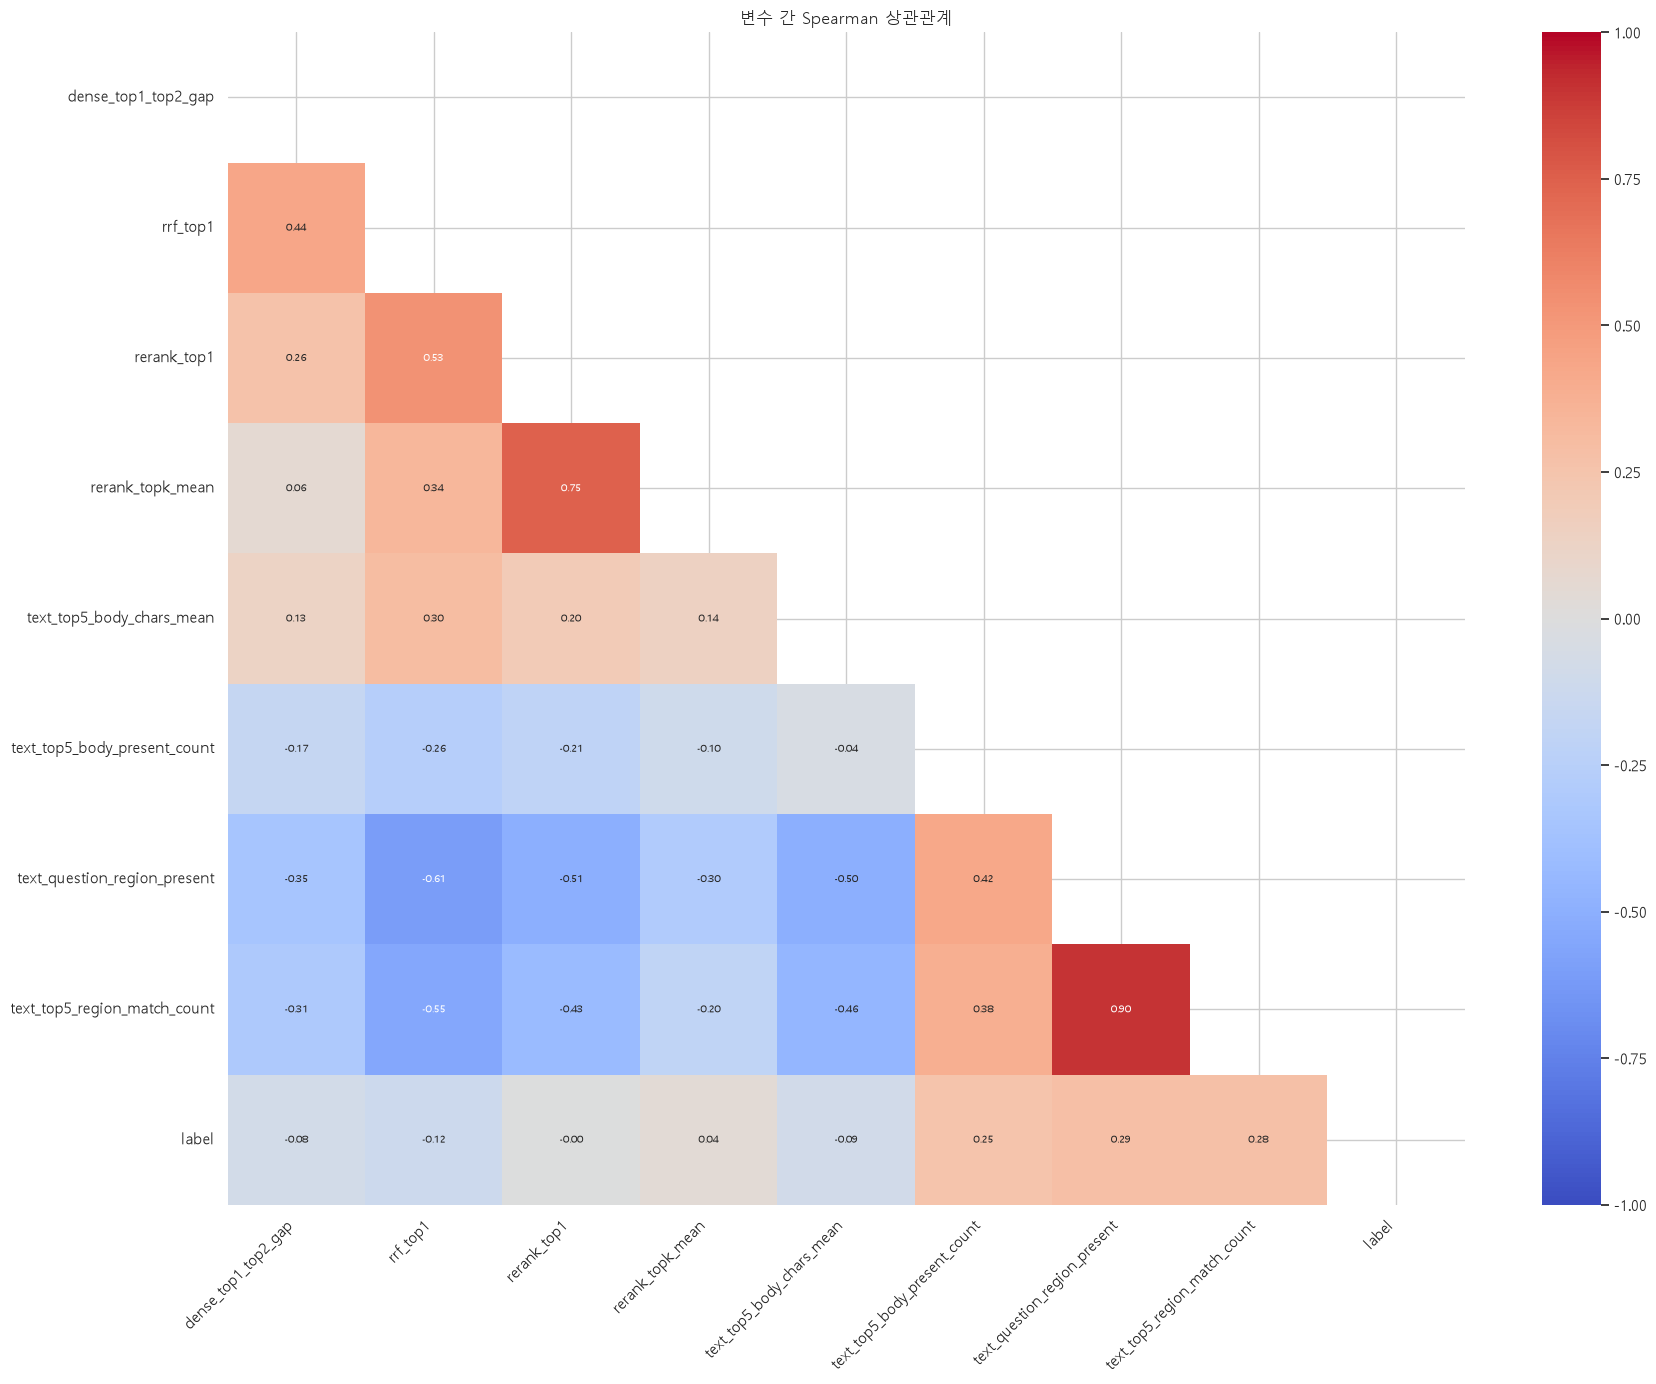

In [156]:
import numpy as np

# Spearman 상관관계
corr = df.corr(
    numeric_only=True,
    method='spearman'
)

# 위쪽 삼각형 숨기기
mask = np.triu(
    np.ones_like(corr, dtype=bool)
)

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    annot_kws={'size': 7}
)

plt.title('변수 간 Spearman 상관관계')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [172]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,y,
    test_size=0.3,
    stratify=y,
    random_state=SEED
)
print(
    len(X_train),
    len(X_valid),
    len(y_train),
    len(y_valid)
)

700 300 700 300


In [173]:
X_valid, X_test, y_valid, y_test = train_test_split(
    X_valid,y_valid,
    test_size=0.5,
    stratify=y_valid,
    random_state=SEED  
)

print(
    len(X_train),
    len(X_valid),
    len(X_test),
    len(y_train),
    len(y_valid),
    len(y_test)
)

700 150 150 700 150 150


In [130]:
rf_model = RandomForestClassifier(random_state=SEED)
# lr_model = LogisticRegression(random_state=SEED)
# xg_model = XGBClassifier()
# cat_model = CatBoostClassifier(random_seed=SEED)

rf_model.fit(X_train, y_train)
print('학습완료')

학습완료


In [131]:
rf_pred = rf_model.predict(X_valid)

rf_as = accuracy_score(y_valid, rf_pred)
rf_ps = precision_score(y_valid, rf_pred)
rf_rs = recall_score(y_valid, rf_pred)
rf_f1 = f1_score(y_valid, rf_pred)

print(f'RandomForest의 정확도: {rf_as}')
print(f'RandomForest의 정밀도: {rf_ps}')
print(f'RandomForest의 재현율: {rf_rs}')
print(f'RandomForest의 f1-score: {rf_f1}')

RandomForest의 정확도: 0.7533333333333333
RandomForest의 정밀도: 0.8015873015873016
RandomForest의 재현율: 0.8938053097345132
RandomForest의 f1-score: 0.8451882845188284


In [132]:
parameters = {
    'max_depth' : [2, 5, 10, 20],
    'min_samples_split' : [2, 4, 8],
    'min_samples_leaf' : [2, 4, 8]
}

grid_rf = GridSearchCV(
    rf_model, 
    param_grid=parameters, 
    scoring='recall', 
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print(f'최적화 파라미터 : {grid_rf.best_params_}')

최적화 파라미터 : {'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [133]:
best_rf = grid_rf.best_params_
Orf_model = RandomForestClassifier(**best_rf, random_state=SEED)

Orf_model.fit(X_train, y_train)
print('학습완료')

학습완료


In [134]:
orf_pred = Orf_model.predict(X_valid)

orf_pred_train = Orf_model.predict(X_train)
orf_pred_valid = Orf_model.predict(X_valid)

print(classification_report(y_train, orf_pred_train, zero_division=0))
print(classification_report(y_valid, orf_pred_valid, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       176
           1       0.75      1.00      0.86       524

    accuracy                           0.75       700
   macro avg       0.37      0.50      0.43       700
weighted avg       0.56      0.75      0.64       700

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        37
           1       0.75      1.00      0.86       113

    accuracy                           0.75       150
   macro avg       0.38      0.50      0.43       150
weighted avg       0.57      0.75      0.65       150



In [180]:
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth' : [2, 3, 5, 10, 20],
    'min_samples_split' : [2, 3, 5, 10],
    'min_samples_leaf' : [1, 5, 8, 16],
    'class_weight': ['balanced', 'balanced_subsample']
}

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1_macro',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    ),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_depth': 10, 'class_weight': 'balanced_subsample'}
0.6325188729885151


In [181]:
rs_best_params = random_search.best_params_

arf_model = RandomForestClassifier(**rs_best_params)

arf_model.fit(X_train, y_train)
print('학습완료')

학습완료


In [182]:
arf_pred = arf_model.predict(X_valid)

arf_pred_train = arf_model.predict(X_train)
arf_pred_valid = arf_model.predict(X_valid)

print(classification_report(y_train, arf_pred_train, zero_division=0))
print(classification_report(y_valid, arf_pred_valid, zero_division=0))

              precision    recall  f1-score   support

           0       0.57      0.80      0.67       176
           1       0.92      0.80      0.86       524

    accuracy                           0.80       700
   macro avg       0.75      0.80      0.76       700
weighted avg       0.83      0.80      0.81       700

              precision    recall  f1-score   support

           0       0.50      0.68      0.57        37
           1       0.88      0.78      0.83       113

    accuracy                           0.75       150
   macro avg       0.69      0.73      0.70       150
weighted avg       0.79      0.75      0.76       150



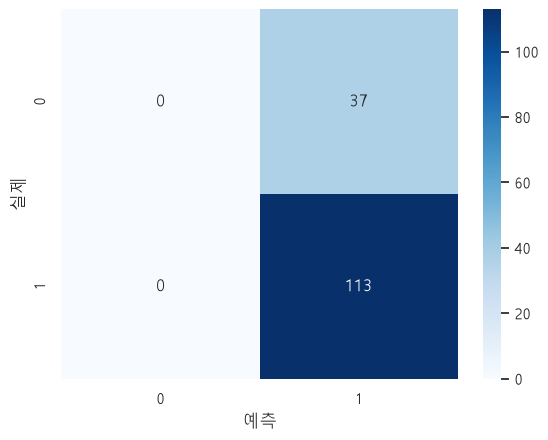

In [94]:
cm = confusion_matrix(y_valid, orf_pred_valid)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.show()

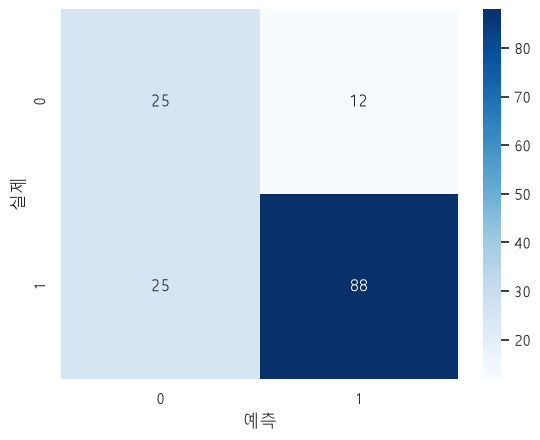

In [183]:
cm = confusion_matrix(y_valid, arf_pred_valid)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.show()

In [139]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=SEED
    ))
])
lr_model.fit(X_train, y_train)
print('학습완료')

학습완료


In [140]:
lr_pred = lr_model.predict(X_valid)

lr_pred_train = lr_model.predict(X_train)
lr_pred_valid = lr_model.predict(X_valid)

print(classification_report(y_train, lr_pred_train, zero_division=0))
print(classification_report(y_valid, lr_pred_valid, zero_division=0))

              precision    recall  f1-score   support

           0       0.60      0.19      0.29       176
           1       0.78      0.96      0.86       524

    accuracy                           0.76       700
   macro avg       0.69      0.57      0.58       700
weighted avg       0.73      0.76      0.72       700

              precision    recall  f1-score   support

           0       0.83      0.14      0.23        37
           1       0.78      0.99      0.87       113

    accuracy                           0.78       150
   macro avg       0.81      0.56      0.55       150
weighted avg       0.79      0.78      0.71       150



In [141]:
param_distributions = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__l1_ratio': [0, 1],   # 0 = L2, 1 = L1
    'model__solver': ['saga'],
    'model__class_weight': [None, 'balanced'],
    'model__max_iter': [1000, 2000, 3000]
}

random_search = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1_macro',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    ),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print('최적 파라미터:', random_search.best_params_)
print('최적 점수:', random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
최적 파라미터: {'model__solver': 'saga', 'model__max_iter': 1000, 'model__l1_ratio': 1, 'model__class_weight': 'balanced', 'model__C': 10}
최적 점수: 0.6082841970507502


In [142]:
rs_best_params = random_search.best_params_

olr_model = random_search.best_estimator_

print(rs_best_params)
print('최적 모델 준비 완료')

{'model__solver': 'saga', 'model__max_iter': 1000, 'model__l1_ratio': 1, 'model__class_weight': 'balanced', 'model__C': 10}
최적 모델 준비 완료


In [143]:
olr_pred = olr_model.predict(X_valid)

olr_pred_train = olr_model.predict(X_train)
olr_pred_valid = olr_model.predict(X_valid)

print(classification_report(y_train, olr_pred_train, zero_division=0))
print(classification_report(y_valid, olr_pred_valid, zero_division=0))

              precision    recall  f1-score   support

           0       0.41      0.73      0.52       176
           1       0.88      0.64      0.74       524

    accuracy                           0.66       700
   macro avg       0.64      0.69      0.63       700
weighted avg       0.76      0.66      0.69       700

              precision    recall  f1-score   support

           0       0.41      0.68      0.51        37
           1       0.87      0.68      0.76       113

    accuracy                           0.68       150
   macro avg       0.64      0.68      0.64       150
weighted avg       0.75      0.68      0.70       150



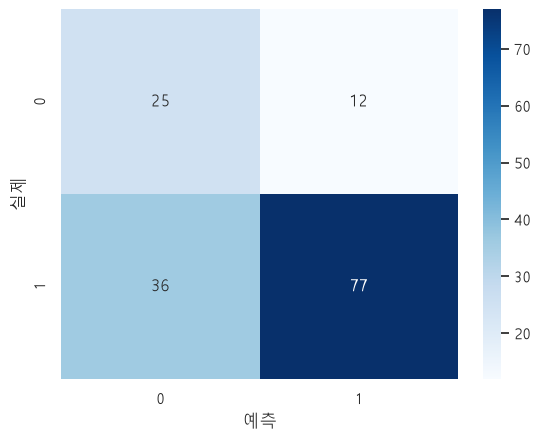

In [146]:
cm = confusion_matrix(y_valid, olr_pred_valid)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.show()

In [147]:
xgb_model = XGBClassifier(
    random_state=SEED,
    n_jobs=1
)
xgb_model.fit(X_train, y_train)
print('학습완료')

xgb_pred_train = xgb_model.predict(X_train)
xgb_pred_valid = xgb_model.predict(X_valid)

print(classification_report(y_train, xgb_pred_train, zero_division=0))
print(classification_report(y_valid, xgb_pred_valid, zero_division=0))

학습완료
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       176
           1       1.00      1.00      1.00       524

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700

              precision    recall  f1-score   support

           0       0.52      0.43      0.47        37
           1       0.82      0.87      0.84       113

    accuracy                           0.76       150
   macro avg       0.67      0.65      0.66       150
weighted avg       0.75      0.76      0.75       150



In [148]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=SEED,
    n_jobs=1,
)

scores = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
    return_train_score=True,
    n_jobs=1,
)

for metric in ("accuracy", "macro_f1"):
    print(f"{metric} Train: {scores[f'train_{metric}'].mean():.3f}")
    print(f"{metric} CV:    {scores[f'test_{metric}'].mean():.3f}")
    print(f"{metric} fold별 CV: {scores[f'test_{metric}']}")

accuracy Train: 1.000
accuracy CV:    0.707
accuracy fold별 CV: [0.69285714 0.65714286 0.77142857 0.70714286 0.70714286]
macro_f1 Train: 1.000
macro_f1 CV:    0.581
macro_f1 fold별 CV: [0.55965182 0.49090909 0.66854099 0.59778572 0.58926655]


In [149]:
param_distributions = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3],
    'min_child_weight': [3, 5],
    'subsample': [0.7, 0.85, 1.0],
    'reg_lambda' : [1, 3, 10]
}

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=SEED,
    n_jobs=1
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1_macro',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    ),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

xgb_best_params = random_search.best_params_
print(xgb_best_params)
axgb_model = random_search.best_estimator_

axgb_pred = axgb_model.predict(X_valid)

axgb_pred_train = axgb_model.predict(X_train)
axgb_pred_valid = axgb_model.predict(X_valid)

print(classification_report(y_train, axgb_pred_train, zero_division=0))
print(classification_report(y_valid, axgb_pred_valid, zero_division=0))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'subsample': 0.7, 'reg_lambda': 10, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05}
              precision    recall  f1-score   support

           0       0.90      0.49      0.63       176
           1       0.85      0.98      0.91       524

    accuracy                           0.86       700
   macro avg       0.87      0.73      0.77       700
weighted avg       0.86      0.86      0.84       700

              precision    recall  f1-score   support

           0       0.65      0.46      0.54        37
           1       0.84      0.92      0.88       113

    accuracy                           0.81       150
   macro avg       0.75      0.69      0.71       150
weighted avg       0.79      0.81      0.79       150



In [75]:
# If needed, install Optuna in the notebook environment and restart the kernel.
import optuna
from sklearn.model_selection import cross_val_score

def optuna_xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 3),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 6),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 10.0, log=True),
    }
    model = XGBClassifier(
        **params, objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', random_state=SEED, n_jobs=1
    )
    scores = cross_val_score(
        model, X_train, y_train, scoring='f1_macro',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        n_jobs=1
    )
    return float(scores.mean())

optuna_xgb_study = optuna.create_study(
    direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED)
)
optuna_xgb_study.optimize(optuna_xgb_objective, n_trials=25, show_progress_bar=False)
print('CV macro F1:', optuna_xgb_study.best_value)
print('Best parameters:', optuna_xgb_study.best_params)

optuna_xgb_model = XGBClassifier(
    **optuna_xgb_study.best_params, objective='binary:logistic',
    eval_metric='logloss', tree_method='hist', random_state=SEED, n_jobs=1
)
optuna_xgb_model.fit(X_train, y_train)
optuna_xgb_pred_train = optuna_xgb_model.predict(X_train)
optuna_xgb_pred_valid = optuna_xgb_model.predict(X_valid)
print('Train:')
print(classification_report(y_train, optuna_xgb_pred_train, zero_division=0))
print('Validation:')
print(classification_report(y_valid, optuna_xgb_pred_valid, zero_division=0))
optuna_xgb_cm = confusion_matrix(y_valid, optuna_xgb_pred_valid, labels=[0, 1])
print('Insufficient -> sufficient (FP):', int(optuna_xgb_cm[0, 1]))
print('FPR:', optuna_xgb_cm[0, 1] / optuna_xgb_cm[0].sum() if optuna_xgb_cm[0].sum() else float('nan'))

[I 2026-09-21 09:05:43,338] A new study created in memory with name: no-name-4449c4f6-a076-4960-a284-9aea80449b97
[I 2026-09-21 09:05:44,349] Trial 0 finished with value: 0.6018990628101127 and parameters: {'n_estimators': 150, 'learning_rate': 0.09423875899553878, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.7468055921327309, 'reg_lambda': 1.4321698289111515}. Best is trial 0 with value: 0.6018990628101127.
[I 2026-09-21 09:05:45,098] Trial 1 finished with value: 0.5904828135633642 and parameters: {'n_estimators': 100, 'learning_rate': 0.08511896829547756, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.7061753482887407, 'reg_lambda': 9.330606024425668}. Best is trial 0 with value: 0.6018990628101127.
[I 2026-09-21 09:05:46,670] Trial 2 finished with value: 0.585056880016678 and parameters: {'n_estimators': 300, 'learning_rate': 0.038739040741088984, 'max_depth': 2, 'min_child_weight': 3, 'subsample': 0.7912726728878613, 'reg_lambda': 3.347776308515933}. Best is trial 0

CV macro F1: 0.623241392164474
Best parameters: {'n_estimators': 250, 'learning_rate': 0.07006227957511041, 'max_depth': 2, 'min_child_weight': 6, 'subsample': 0.7098791502303166, 'reg_lambda': 7.00855458506785}
Train:
              precision    recall  f1-score   support

           0       0.93      0.56      0.70       176
           1       0.87      0.98      0.92       524

    accuracy                           0.88       700
   macro avg       0.90      0.77      0.81       700
weighted avg       0.88      0.88      0.87       700

Validation:
              precision    recall  f1-score   support

           0       0.68      0.35      0.46        37
           1       0.82      0.95      0.88       113

    accuracy                           0.80       150
   macro avg       0.75      0.65      0.67       150
weighted avg       0.78      0.80      0.78       150

Insufficient -> sufficient (FP): 24
FPR: 0.6486486486486487


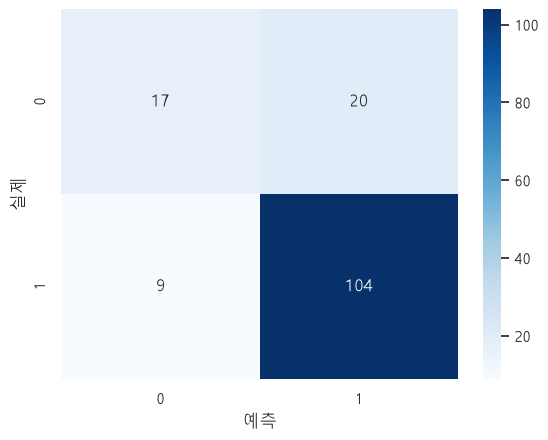

In [150]:
cm = confusion_matrix(y_valid, axgb_pred_valid, labels=[0, 1])

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.show()

In [106]:
cat_model = CatBoostClassifier(
    random_state=SEED
)
cat_model.fit(X_train, y_train)
print('학습완료')

cat_pred = cat_model.predict(X_valid)

cat_pred_train = cat_model.predict(X_train)
cat_pred_valid = cat_model.predict(X_valid)

print(classification_report(y_train, cat_pred_train, zero_division=0))
print(classification_report(y_valid, cat_pred_valid, zero_division=0))

Learning rate set to 0.008847
0:	learn: 0.6893522	total: 4.55ms	remaining: 4.54s
1:	learn: 0.6850555	total: 12ms	remaining: 5.99s
2:	learn: 0.6815565	total: 18.4ms	remaining: 6.13s
3:	learn: 0.6774073	total: 22.1ms	remaining: 5.5s
4:	learn: 0.6730605	total: 28.9ms	remaining: 5.75s
5:	learn: 0.6698500	total: 31.8ms	remaining: 5.27s
6:	learn: 0.6664670	total: 35.7ms	remaining: 5.07s
7:	learn: 0.6627227	total: 40ms	remaining: 4.96s
8:	learn: 0.6590653	total: 44.1ms	remaining: 4.86s
9:	learn: 0.6556579	total: 46.8ms	remaining: 4.63s
10:	learn: 0.6523049	total: 49.4ms	remaining: 4.44s
11:	learn: 0.6490490	total: 52.1ms	remaining: 4.29s
12:	learn: 0.6463411	total: 55.5ms	remaining: 4.22s
13:	learn: 0.6432357	total: 58.2ms	remaining: 4.1s
14:	learn: 0.6401147	total: 60.7ms	remaining: 3.98s
15:	learn: 0.6368770	total: 63.2ms	remaining: 3.88s
16:	learn: 0.6340584	total: 65.8ms	remaining: 3.81s
17:	learn: 0.6310742	total: 68.4ms	remaining: 3.73s
18:	learn: 0.6277885	total: 71.7ms	remaining: 3.7s

In [174]:
param_distributions = {
    'iterations': [100, 200, 300, 500],
    'depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 10],
    'random_strength': [0.5, 1, 2, 5],
    'border_count': [32, 64, 128]
}

cat_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='F1',
    auto_class_weights='Balanced',
    random_seed = SEED,
    verbose=0
)

random_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1_macro',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    ),
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

ocat_model = random_search.best_estimator_

ocat_pred_train = ocat_model.predict(X_train)
ocat_pred_valid = ocat_model.predict(X_valid)

print(classification_report(y_train, ocat_pred_train, zero_division=0))
print(classification_report(y_valid, ocat_pred_valid, zero_division=0))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
              precision    recall  f1-score   support

           0       0.51      0.81      0.62       176
           1       0.92      0.73      0.82       524

    accuracy                           0.75       700
   macro avg       0.71      0.77      0.72       700
weighted avg       0.82      0.75      0.77       700

              precision    recall  f1-score   support

           0       0.47      0.76      0.58        37
           1       0.90      0.73      0.80       113

    accuracy                           0.73       150
   macro avg       0.69      0.74      0.69       150
weighted avg       0.80      0.73      0.75       150



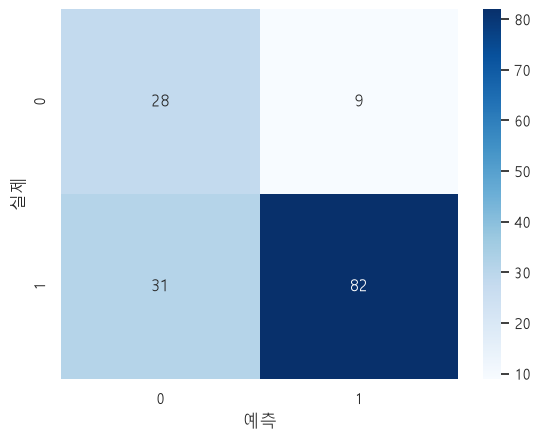

In [175]:
cm = confusion_matrix(y_valid, ocat_pred_valid)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.show()

In [161]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    ocat_model,
    X_valid,
    y_valid,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance": result.importances_mean
}).sort_values(
    "importance",
    ascending=False
)

importance_df

,feature,importance
6,text_question_region_present,0.099509
7,text_top5_region_match_count,0.057414
2,rerank_top1,0.056153
4,text_top5_body_chars_mean,0.031334
5,text_top5_body_present_count,0.022996
3,rerank_topk_mean,0.021818
0,dense_top1_top2_gap,0.021090
1,rrf_top1,0.010639


## 질문 TF-IDF + 선형 분류기 실험 (Test 미사용)

맨 위 셀에서 읽은 `teacher_features_text_v1.csv`의 `question`만 사용합니다. 기존 700/150/150 분할의 행 인덱스를 그대로 쓰며, TF-IDF는 Pipeline 안에서 각 Train CV fold에만 fit됩니다. 현재 CSV에는 Top-5 근거 원문이 없으므로 이 결과는 **질문만으로 Teacher 라벨을 예측하는 기준선**입니다. 근거 충분성 판단을 대체했다는 뜻이 아니며, 검증 정확도가 높아도 질문 표현/범주에 따른 지름길 학습 가능성을 확인해야 합니다. Test는 모델·파라미터·임계값을 확정하기 전까지 사용하지 않습니다.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 기존 분할의 인덱스로 원본 CSV 질문을 가져온다. Test 질문/라벨은 여기서 읽지 않는다.
assert data['case_id'].is_unique, 'case_id 중복을 먼저 확인하세요.'
assert set(X_train.index).isdisjoint(X_valid.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_valid.index).isdisjoint(X_test.index)
tfidf_train_text = data.loc[X_train.index, 'question'].fillna('').astype(str)
tfidf_valid_text = data.loc[X_valid.index, 'question'].fillna('').astype(str)
tfidf_train_y = y_train.loc[tfidf_train_text.index]
tfidf_valid_y = y_valid.loc[tfidf_valid_text.index]

# 한국어 질문의 띄어쓰기/형태소 분석기 의존성을 피하기 위한 문자 n-gram.
tfidf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
tfidf_cv_groups = data.loc[tfidf_train_text.index, 'category'].astype(str) + '_' + tfidf_train_y.astype(str)
tfidf_cv_splits = list(tfidf_cv.split(tfidf_train_text, tfidf_cv_groups))
tfidf_models = {
    'Linear SVM': LinearSVC(random_state=SEED, max_iter=5000),
    'Logistic Regression': LogisticRegression(solver='liblinear', max_iter=2000, random_state=SEED),
}
tfidf_searches = {}
for model_name, classifier in tfidf_models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(2, 4), min_df=2,
                                  max_features=50000, sublinear_tf=True)),
        ('clf', classifier),
    ])
    search = GridSearchCV(
        pipeline,
        {'clf__C': [0.1, 1.0, 10.0], 'clf__class_weight': [None, 'balanced']},
        scoring='f1_macro', cv=tfidf_cv_splits, n_jobs=1,
        return_train_score=True, refit=True, error_score='raise',
    )
    search.fit(tfidf_train_text, tfidf_train_y)
    tfidf_searches[model_name] = search
    best_row = search.best_index_
    print(model_name, 'best:', search.best_params_,
          'Train CV macro F1:', round(search.best_score_, 4),
          'Train-fold macro F1:', round(search.cv_results_['mean_train_score'][best_row], 4))

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

tfidf_validation_rows = []
for model_name, search in tfidf_searches.items():
    pred = search.predict(tfidf_valid_text)
    tn, fp, fn, tp = confusion_matrix(tfidf_valid_y, pred, labels=[0, 1]).ravel()
    tfidf_validation_rows.append({
        'model': model_name,
        'cv_macro_f1': search.best_score_,
        'valid_accuracy': accuracy_score(tfidf_valid_y, pred),
        'valid_macro_f1': f1_score(tfidf_valid_y, pred, average='macro'),
        'valid_insufficient_recall': tn / (tn + fp) if tn + fp else float('nan'),
        'valid_fp_0_to_1': int(fp),
        'valid_fpr': fp / (tn + fp) if tn + fp else float('nan'),
    })
    print('\n', model_name, 'Validation confusion matrix [[TN, FP], [FN, TP]]:',
          [[int(tn), int(fp)], [int(fn), int(tp)]])
    print(classification_report(tfidf_valid_y, pred, labels=[0, 1], zero_division=0))
tfidf_validation_results = pd.DataFrame(tfidf_validation_rows)
display(tfidf_validation_results)
print('Validation 결과는 탐색용입니다. Test는 아직 평가하지 않았습니다.')

## TF-IDF 고도화: 질문 / 질문+Top-5 근거 / 근거+36개 수치 Feature

위의 질문-only 실험을 기준선으로 남기고, 아래에서 동일한 고정 분할로 세 입력(A/B/C)과 두 선형 모델을 비교합니다. `teacher_audit.csv`는 실제 Judge가 본 Top-5 근거 원문만 가져오며 `eval_gold_*`는 입력에 넣지 않습니다. Train 5-fold에서만 TF-IDF 어휘·스케일러·임계값을 학습합니다. 실행은 로컬 CSV만 읽고 OpenAI/Cohere/LLM API를 호출하지 않습니다. 기본 보고서가 있으면 원본 해시를 확인하고 불러옵니다. 새 실험을 원하면 `tfidf_output_dir`을 새 폴더로 바꾸세요. Test는 이 셀에서 실행하지 않습니다.

In [ ]:
from pathlib import Path
import sys, json, hashlib

llm_root = Path.cwd().parent if Path.cwd().name == 'ML' else Path.cwd()
if str(llm_root) not in sys.path:
    sys.path.insert(0, str(llm_root))
from ML.tfidf_judge_experiment import run_experiment

tfidf_source = llm_root / 'data/processed/judge_v2/teacher_features_text_v1.csv'
tfidf_audit = llm_root / 'data/processed/judge_v2/teacher_audit.csv'
tfidf_output_dir = llm_root / 'data/processed/judge_v2/tfidf_v2'
tfidf_report_path = tfidf_output_dir / 'search_results.json'
if tfidf_report_path.exists():
    tfidf_report = json.loads(tfidf_report_path.read_text(encoding='utf-8'))
    if (tfidf_report['source_sha256'] != hashlib.sha256(tfidf_source.read_bytes()).hexdigest()
            or tfidf_report['audit_sha256'] != hashlib.sha256(tfidf_audit.read_bytes()).hexdigest()):
        raise ValueError('보고서 생성 당시와 원본 CSV가 다릅니다. 새 출력 폴더로 재실행하세요.')
else:
    tfidf_report = run_experiment(
        source=tfidf_source, audit_path=tfidf_audit, output=tfidf_output_dir,
        trials=12, folds=5,
    )
tfidf_summary = pd.DataFrame([
    {'input': row['arm'], 'model': row['model'],
     'cv_accuracy': row['cv']['accuracy'],
     'cv_macro_f1': row['cv']['macro_f1'],
     'cv_fpr': row['cv']['fpr'],
     'train_cv_gap': row['train_cv_accuracy_gap'],
     'threshold': row['threshold'],
     'validation_accuracy': row['validation']['accuracy'],
     'validation_macro_f1': row['validation']['macro_f1'],
     'validation_fp': row['validation']['fp_0_to_1'],
     'validation_fpr': row['validation']['fpr']}
    for row in tfidf_report['summary']
])
display(tfidf_summary)
print('선정:', tfidf_report['selected'], 'Validation 기준 통과:', tfidf_report['validation_target_met'])
print('상세 보고서:', tfidf_output_dir / 'search_results.md')
print('Test는 실행하지 않았습니다.')